# Exploratory Data Analysis: Google Play Store Dataset

This project explores the Google Play Store dataset to uncover insights into app categories, ratings, installs, pricing, and user sentiment.  
The goal is to answer business-driven questions about what drives app success in the digital marketplace.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
apps = pd.read_csv("/kaggle/input/datasets/aadeshdixit11/play-store-android-app-data/googleplaystore.csv")
reviews = pd.read_csv("/kaggle/input/datasets/aadeshdixit11/play-store-android-app-data/googleplaystore_user_reviews.csv")

We import Pandas, NumPy, Matplotlib, and Seaborn for data manipulation and visualization.  
Two datasets are loaded: `apps` (metadata) and `reviews` (user sentiment).

In [76]:
# Check basic info
apps.info()
apps.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [77]:
# Convert Reviews to numeric
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')
apps = apps.dropna(subset=['Reviews'])
apps['Reviews'] = apps['Reviews'].astype(int)

# Convert Installs to integer
apps['Installs'] = apps['Installs'].str.replace('+','', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',','', regex=False)
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Convert Price to float
apps['Price'] = apps['Price'].str.replace('$','', regex=False)
apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

# Convert Last Updated to date time
apps['Last Updated'] = pd.to_datetime(apps['Last Updated'], errors='coerce')

# Convert Size_MB to numeric
def size_to_mb(size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024
    else:
        return np.nan  # for "Varies with device"

apps['Size_MB'] = apps['Size'].apply(size_to_mb)

## Data Type Conversion

We converted key columns into proper numeric and datetime formats:
- `Reviews` → integer
- `Installs` → integer (removed “+” and “,”)
- `Price` → float (removed “$”)
- `Last Updated` → datetime
- `Size` → standardized into MB

This ensures accurate statistical analysis and visualization in later steps.

In [78]:
# Recheck data after conversion
apps.info()
apps.head()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            10840 non-null  object        
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Size_MB         9145 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(8)
memor

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8


---

In [79]:
# Check Missing Values
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
Size_MB           1695
dtype: int64

In [80]:
# Handle Missing Ratings
apps = apps.dropna(subset=['Rating'])

# Handle Other Missing Values
apps['Type'] = apps['Type'].fillna('Unknown')
apps['Content Rating'] = apps['Content Rating'].fillna('Unknown')
apps['Current Ver'] = apps['Current Ver'].fillna('Unknown')
apps['Android Ver'] = apps['Android Ver'].fillna('Unknown')

# Handle Duplicates
apps = apps.drop_duplicates(subset='App')

## Handling Missing Values & Duplicates

- Dropped rows with missing `Rating` values to preserve analysis integrity.
- Filled missing categorical values (`Type`, `Content Rating`, `Current Ver`, `Android Ver`) with `"Unknown"`.
- Removed duplicate apps to ensure uniqueness.
- Final dataset is clean and ready for exploratory analysis.

In [81]:
# Recheck after handeling missing values
apps.isnull().sum()

App                  0
Category             0
Rating               0
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
Size_MB           1169
dtype: int64

---

In [82]:
# Summary Statistics
apps.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
count,8196,8196,8196.000000,8.196000e+03,8196,8.196000e+03,8196,8196.000000,8196,8196,8196,8196,8196,7027.000000
unique,8196,33,NaN,NaN,414,NaN,2,NaN,6,114,NaN,2625,32,NaN
top,iHoroscope - 2018 Daily Horoscope & Astrology,FAMILY,NaN,NaN,Varies with device,NaN,Free,NaN,Everyone,Tools,NaN,Varies with device,4.1 and up,NaN
freq,1,1608,NaN,NaN,1169,NaN,7592,NaN,6618,717,NaN,1011,1811,NaN
mean,NaN,NaN,4.173243,2.552515e+05,NaN,9.165090e+06,NaN,1.037884,NaN,NaN,2017-11-05 05:35:13.616398080,NaN,NaN,21.754060
min,NaN,NaN,1.000000,1.000000e+00,NaN,1.000000e+00,NaN,0.000000,NaN,NaN,2010-05-21 00:00:00,NaN,NaN,0.008301
25%,NaN,NaN,4.000000,1.260000e+02,NaN,1.000000e+04,NaN,0.000000,NaN,NaN,2017-08-17 00:00:00,NaN,NaN,4.900000
50%,NaN,NaN,4.300000,3.004000e+03,NaN,1.000000e+05,NaN,0.000000,NaN,NaN,2018-05-20 00:00:00,NaN,NaN,13.000000
75%,NaN,NaN,4.500000,4.381300e+04,NaN,1.000000e+06,NaN,0.000000,NaN,NaN,2018-07-19 00:00:00,NaN,NaN,31.000000
max,NaN,NaN,5.000000,7.815831e+07,NaN,1.000000e+09,NaN,400.000000,NaN,NaN,2018-08-08 00:00:00,NaN,NaN,100.000000


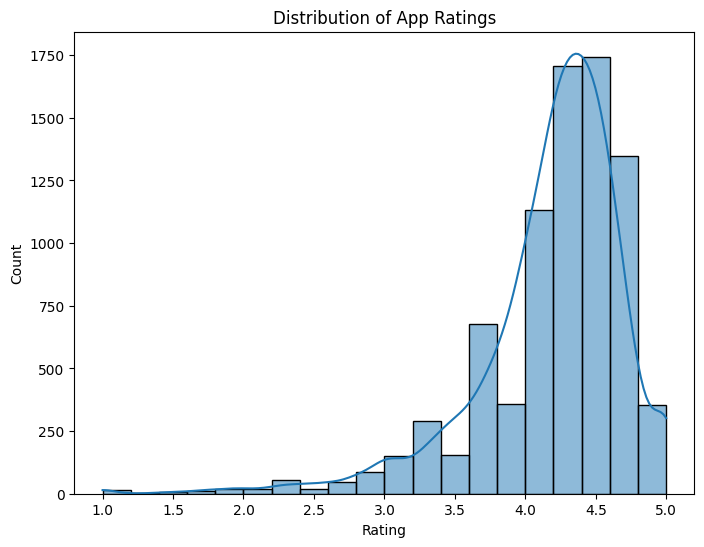

In [83]:
# Distribution of Ratings
plt.figure(figsize=(8,6))
sns.histplot(apps['Rating'], bins=20, kde=True)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Ratings Distribution
**What the chart shows:**  
This histogram displays the spread of app ratings across the Play Store. Most apps cluster between 4.0 and 4.5, with very few apps rated below 3.0.  

**Impact:**  
This indicates a **positive bias in user ratings** — users generally rate apps highly.  
For business analysis, this means ratings alone may not be a strong differentiator. Recruiters or stakeholders should look at **installs and reviews alongside ratings** to identify truly successful apps.

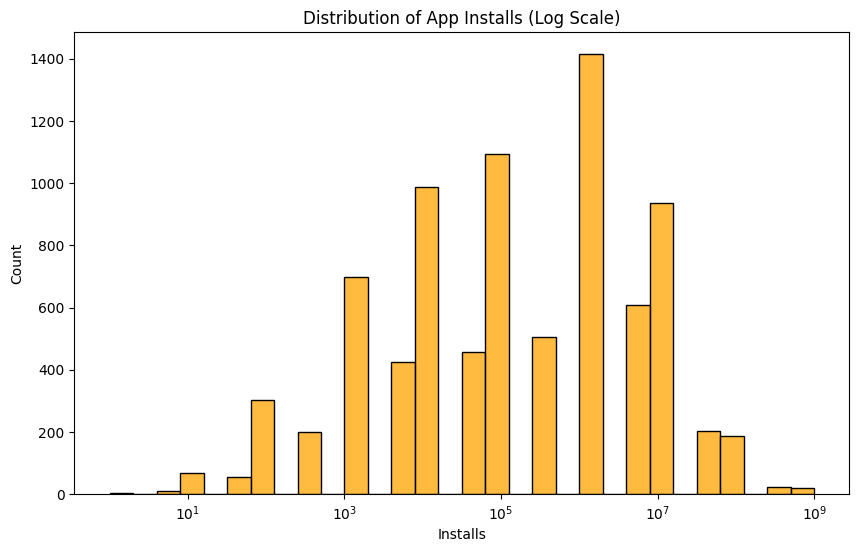

In [84]:
# Installs Distributio
plt.figure(figsize=(10,6))
sns.histplot(apps['Installs'], bins=30, log_scale=True, color='orange')
plt.title("Distribution of App Installs (Log Scale)")
plt.xlabel("Installs")
plt.ylabel("Count")
plt.show()

### Installs Distribution
**What the chart shows:**  
This histogram (with log scale) displays how many installs apps have. Most apps fall into the lower range (under 10,000 installs), while a small number of apps dominate with millions of downloads.  

**Impact:**  
The distribution is highly skewed, showing a **long-tail effect**: only a few apps achieve massive popularity, while the majority struggle to gain traction.  
For business analysis, this highlights the **competitive nature of the app market** — success is concentrated in a small set of apps, and visibility is critical for growth.

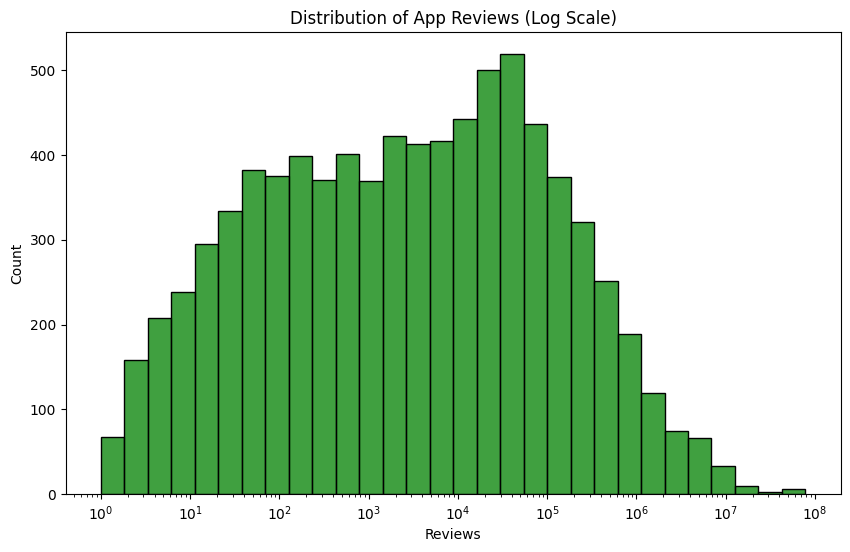

In [85]:
# Reviews Distribution
plt.figure(figsize=(10,6))
sns.histplot(apps['Reviews'], bins=30, log_scale=True, color='green')
plt.title("Distribution of App Reviews (Log Scale)")
plt.xlabel("Reviews")
plt.ylabel("Count")
plt.show()

### Reviews Distribution
**What the chart shows:**  
This histogram (log scale) displays the number of user reviews per app. Most apps have very few reviews (under 100), while a small number of apps attract thousands or even millions of reviews.  

**Impact:**  
The distribution is highly skewed, similar to installs. Reviews act as a **proxy for popularity and user engagement** — apps with more reviews are more visible and trusted, which further boosts installs.  
For business analysis, this highlights the importance of encouraging users to leave reviews, as they directly influence app visibility and success.

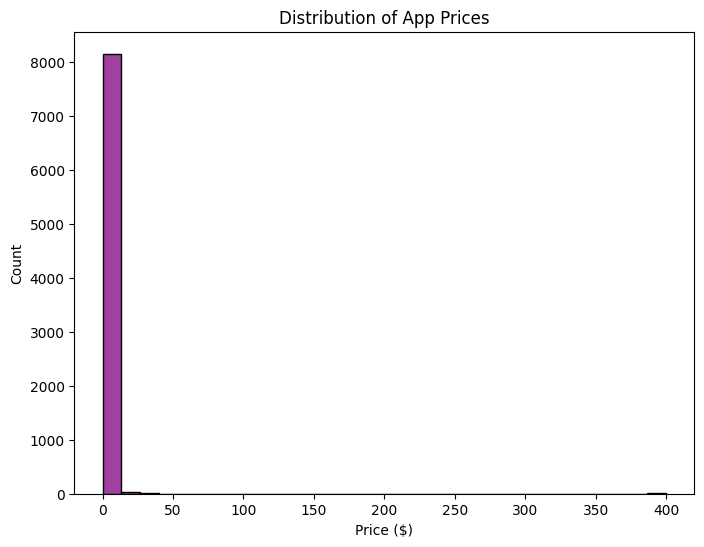

In [86]:
# Price Distribution
plt.figure(figsize=(8,6))
sns.histplot(apps['Price'], bins=30, color='purple')
plt.title("Distribution of App Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

### Price Distribution
**What the chart shows:**  
This histogram displays the distribution of app prices. The majority of apps are free (price = 0). Paid apps are rare, and most are priced below $10. A few extreme outliers exist, with prices reaching hundreds of dollars.  

**Impact:**  
The Play Store is dominated by free apps, which reflects the **freemium business model**. Paid apps are niche, and pricing strategy is critical — successful paid apps usually stay affordable.  
For business analysis, this highlights that monetization often relies on **in-app purchases or ads** rather than upfront pricing.

## Descriptive Statistics & Distributions

In this stage of EDA, we performed the following steps for the key variables (Ratings, Installs, Reviews, Price):

1. **Created visualizations** for each key variable.  
2. **Explained the charts** to interpret the distributions.  
3. **Analyzed the impact** to connect findings with business insights.  

This structured approach ensures that each visualization is not only presented but also contextualized with its meaning and implications.

---

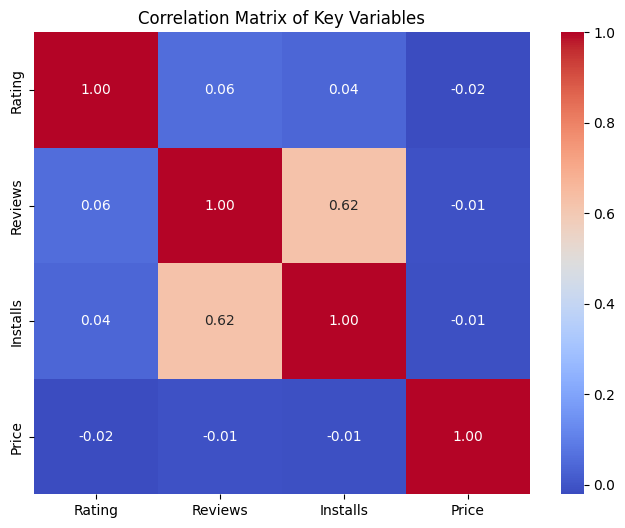

In [87]:
# Correlation Matrix
plt.figure(figsize=(8,6))
corr = apps[['Rating','Reviews','Installs','Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Key Variables")
plt.show()

### Correlation Matrix
**What we did:**  
- Created a heatmap of correlations between `Rating`, `Reviews`, `Installs`, and `Price`.  
- Explained the chart by highlighting positive and negative relationships.  
- Analyzed the impact to understand which factors drive app success.

**Insights:**  
- `Installs` and `Reviews` show a strong positive correlation → popular apps attract more reviews.  
- `Rating` has weak correlation with `Installs` and `Reviews` → high ratings don’t guarantee popularity.  
- `Price` has a negative correlation with `Installs` → free apps dominate in downloads.  

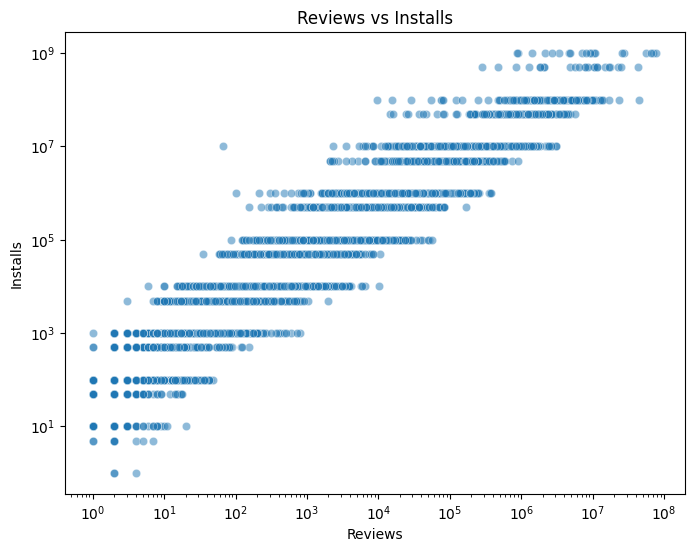

In [88]:
# Reviews vs Installs
plt.figure(figsize=(8,6))
sns.scatterplot(x='Reviews', y='Installs', data=apps, alpha=0.5)
plt.title("Reviews vs Installs")
plt.xlabel("Reviews")
plt.ylabel("Installs")
plt.xscale('log')
plt.yscale('log')
plt.show()

### Reviews vs Installs
**What we did:**  
- Created a scatterplot comparing `Reviews` and `Installs` (log scale).  
- Explained the chart by showing that apps with more installs tend to have more reviews.  
- Analyzed the impact: reviews act as a **proxy for popularity and engagement**, reinforcing installs and visibility.

**Insights:**  
- Reviews act as a **proxy for popularity and engagement**, reinforcing installs and visibility.

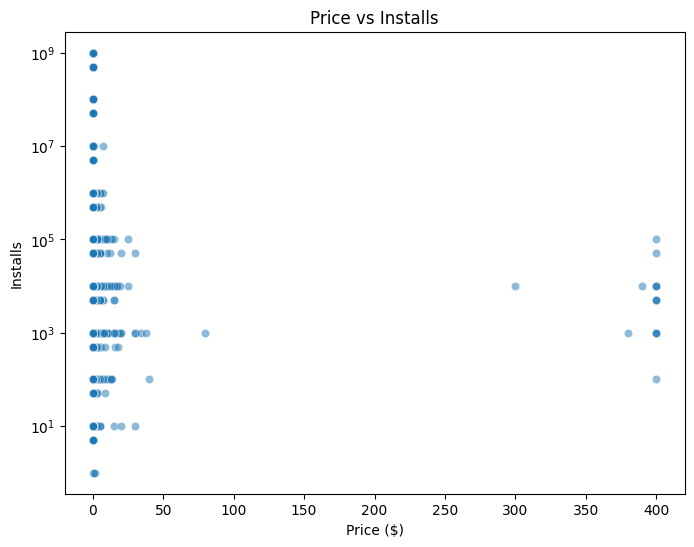

In [89]:
# Price vs Installs
plt.figure(figsize=(8,6)) 
sns.scatterplot(x='Price', y='Installs', data=apps, alpha=0.5) 
plt.title("Price vs Installs") 
plt.xlabel("Price ($)") 
plt.ylabel("Installs") 
plt.yscale('log') 
plt.show()

### Price vs Installs
**What we did:**  
- Created a scatterplot comparing `Price` and `Installs`.  
- Explained the chart by showing that free apps dominate installs, while higher-priced apps have fewer downloads.  

**Insights:**  
- Pricing strategy is critical — most successful apps rely on freemium models rather than upfront costs.

## Correlation Analysis & Matrix

In this step, we analyzed relationships between key variables using a correlation matrix and scatterplots.  
We focused on how `Installs`, `Reviews`, and `Price` interact to drive app success.

**Impact:**  
- Strong positive link between installs and reviews → popular apps attract more engagement.  
- Negative link between price and installs → free apps dominate adoption.  
- Overall, reviews and installs reinforce each other as growth drivers, while pricing strategy directly influences market reach.

---

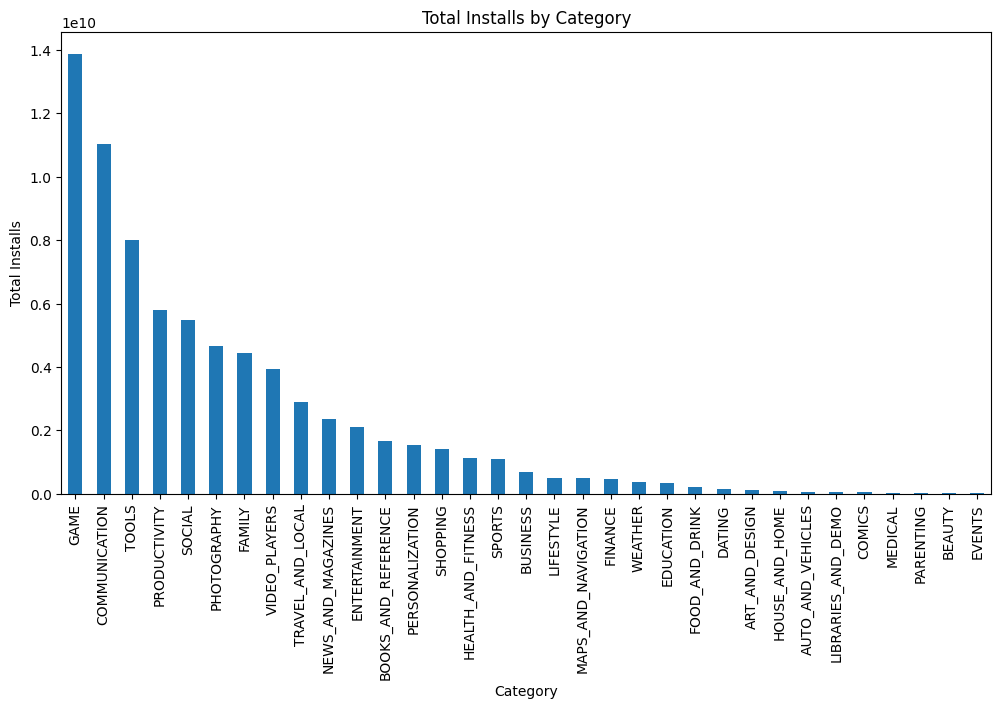

In [90]:
# Installs by Category
plt.figure(figsize=(12,6))
apps.groupby('Category')['Installs'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Total Installs by Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=90)
plt.show()

### Installs by Category
**What the visualization shows:**  
Games, Communication, and Tools categories dominate installs.  

**Impact:**  
Market success is concentrated in a few high‑demand categories, showing where user adoption is strongest.

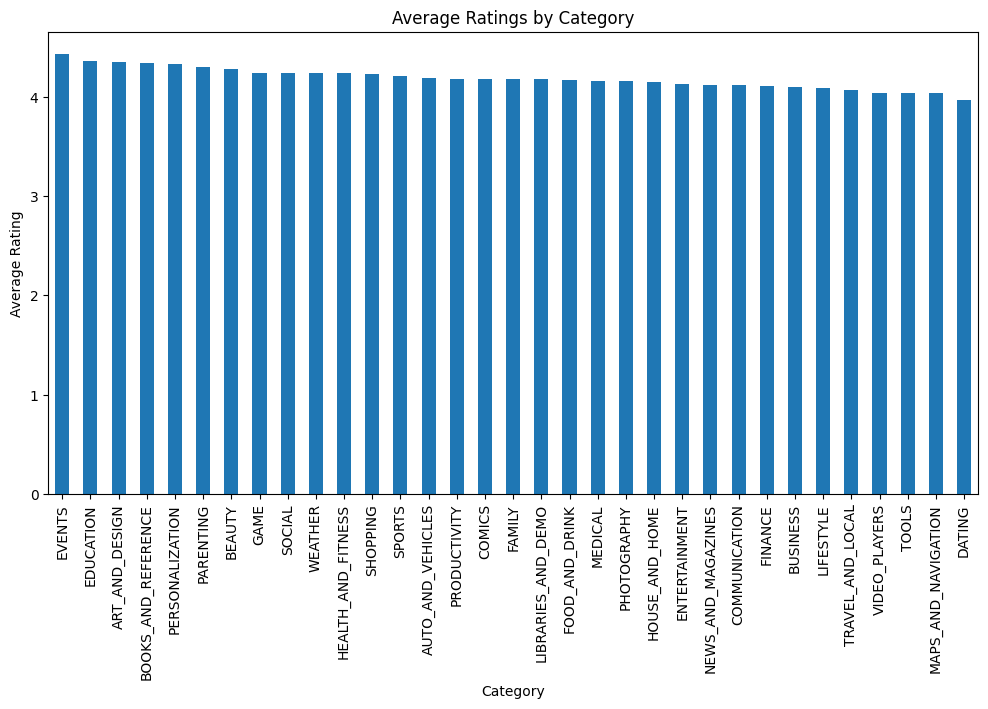

In [91]:
# Ratings by Category
plt.figure(figsize=(12,6))
apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Ratings by Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)
plt.show()

### Ratings by Category
**What the visualization shows:**  
Most categories maintain high average ratings (above 4.0), with Education and Health apps often leading.  

**Impact:**  
Ratings are positively biased across categories, limiting differentiation, but strong ratings in niche categories reflect user satisfaction.

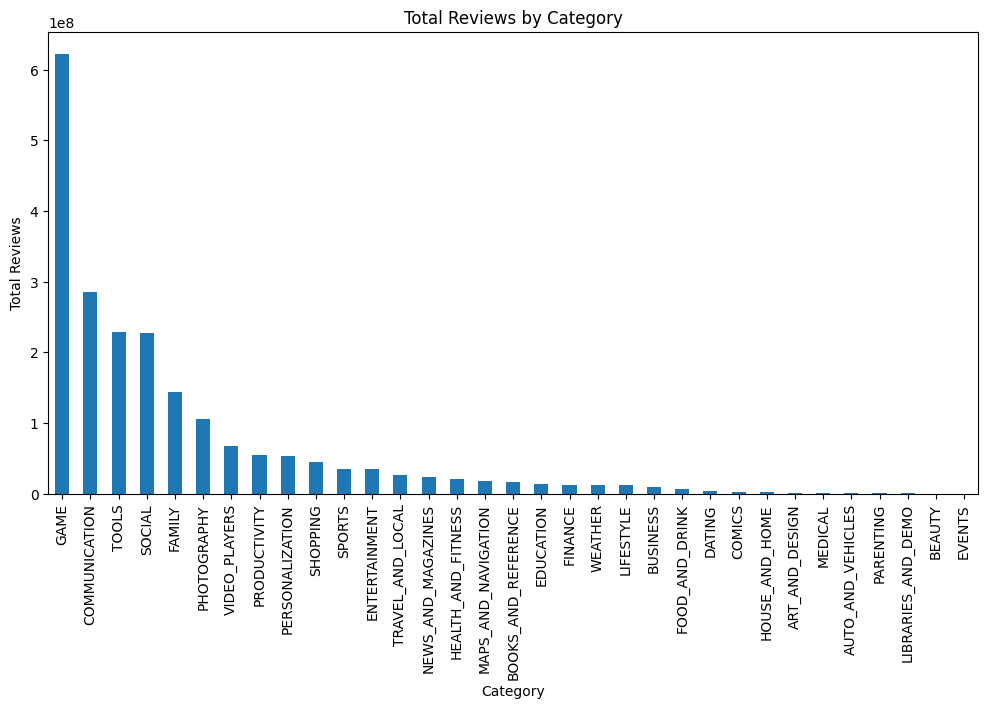

In [92]:
# Reviews by Category
plt.figure(figsize=(12,6))
apps.groupby('Category')['Reviews'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Total Reviews by Category")
plt.ylabel("Total Reviews")
plt.xticks(rotation=90)
plt.show()

### Reviews by Category
**What the visualization shows:**  
Games and Social apps generate the highest number of reviews, reflecting strong engagement.  

**Impact:**  
Categories with more reviews gain visibility and trust, reinforcing growth through user feedback.

## Category‑wise Analysis

In this step, we compared app categories by installs, ratings, and reviews.  
We found that **Games, Communication, and Social apps dominate installs and reviews**, while **Education and Health apps achieve strong ratings**.  

**Impact:** 
- Success is concentrated in entertainment and communication categories, while ratings remain high across the board, showing user satisfaction but limited differentiation.

---

In [93]:
# Top 10 apps by Installs
top_installs = apps.groupby('App')['Installs'].sum().sort_values(ascending=False).head(10)
top_installs = top_installs.reset_index()
top_installs.columns = ['App', 'Total Installs']
print("Top 10 Apps by Installs")
display(top_installs)

Top 10 Apps by Installs


,App,Total Installs
0,WhatsApp Messenger,1000000000
1,YouTube,1000000000
2,Google+,1000000000
3,Hangouts,1000000000
4,Gmail,1000000000
5,Maps - Navigate & Explore,1000000000
6,Facebook,1000000000
7,Messenger – Text and Video Chat for Free,1000000000
8,Google Drive,1000000000
9,Google Chrome: Fast & Secure,1000000000


### Top Apps by Installs
**Impact:**  
These apps dominate user adoption, reflecting strong market presence and visibility.

In [94]:
# Top 10 apps by Reviews
top_reviews = apps.groupby('App')['Reviews'].sum().sort_values(ascending=False).head(10)
top_reviews = top_reviews.reset_index()
top_reviews.columns = ['App', 'Total Reviews']
print("Top 10 Apps by Reviews")
display(top_reviews)

Top 10 Apps by Reviews


,App,Total Reviews
0,Facebook,78158306
1,WhatsApp Messenger,69119316
2,Instagram,66577313
3,Messenger – Text and Video Chat for Free,56642847
4,Clash of Clans,44891723
5,Clean Master- Space Cleaner & Antivirus,42916526
6,Subway Surfers,27722264
7,YouTube,25655305
8,"Security Master - Antivirus, VPN, AppLock, Boo...",24900999
9,Clash Royale,23133508


### Top Apps by Reviews
**Impact:**  
High review counts indicate strong user engagement and feedback loops that reinforce popularity.

In [95]:
# Top 10 apps by Ratings
top_ratings = apps.groupby('App')['Rating'].mean().sort_values(ascending=False).head(10)
top_ratings = top_ratings.reset_index()
top_ratings.columns = ['App', 'Average Rating']
print("Top 10 Apps by Ratings")
display(top_ratings)

Top 10 Apps by Ratings


,App,Average Rating
0,CZ Kompas,5.0
1,CZ-Help,5.0
2,CN Resident,5.0
3,iReadMe,5.0
4,meStudying: AP English Lit,5.0
5,30WPM Amateur ham radio Koch CW Morse code tra...,5.0
6,CL Keyboard - Myanmar Keyboard (No Ads),5.0
7,CL Notifier,5.0
8,CL REPL,5.0
9,CL Strength,5.0


### Top Apps by Ratings
**Impact:**  
These apps achieve strong user satisfaction, though high ratings alone don’t guarantee installs.

## Top Apps Analysis
In this step, we identified the leading apps by installs, reviews, and ratings.

**Impact:** 
- Apps with the most installs and reviews dominate visibility and engagement, while highly rated apps reflect strong satisfaction. Together, these metrics highlight which apps set benchmarks for success in the Play Store.


---

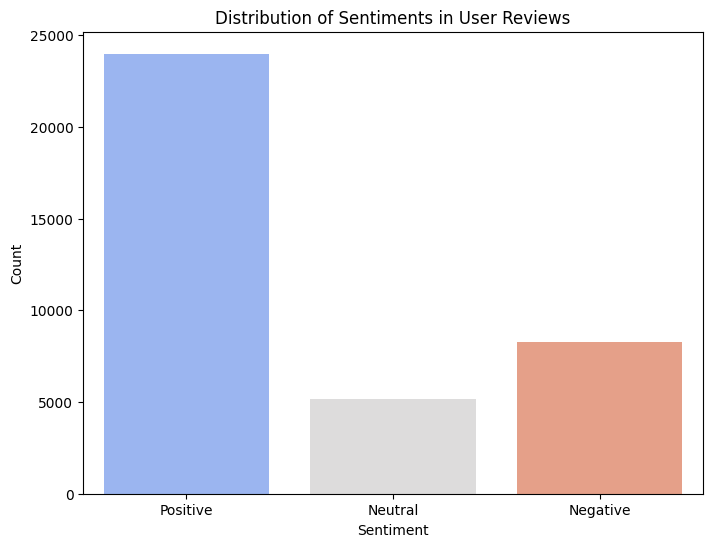

In [96]:
# Sentiment Distribution
plt.figure(figsize=(8,6))
sns.countplot(x='Sentiment', hue='Sentiment', data=reviews, palette='coolwarm', legend=False)
plt.title("Distribution of Sentiments in User Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Sentiment Distribution
**Impact:**  
Most reviews are positive, showing overall user satisfaction. Negative reviews form a smaller but important segment, highlighting areas for improvement.

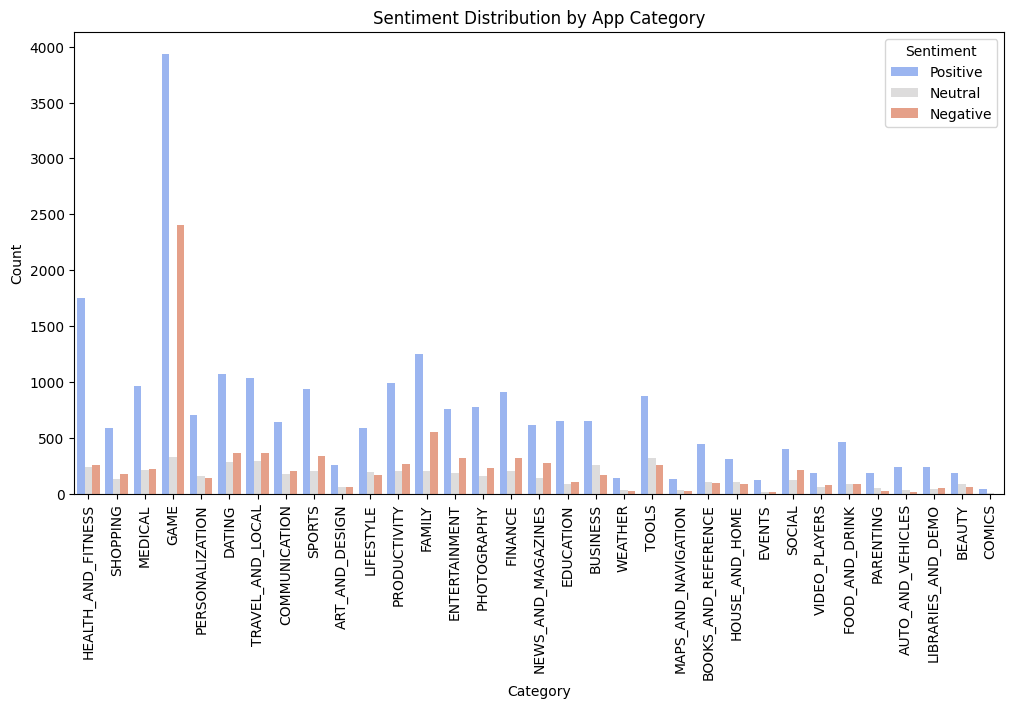

In [97]:
# Merge reviews with apps to bring in Category info
reviews_with_cat = reviews.merge(apps[['App','Category']], on='App', how='left')

# sentiment by category
plt.figure(figsize=(12,6))
sns.countplot(x='Category', hue='Sentiment', data=reviews_with_cat, palette='coolwarm')
plt.title("Sentiment Distribution by App Category")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

### Sentiment by Category
**Impact:**  
Entertainment and Social apps generate the highest volume of both positive and negative sentiments, reflecting strong engagement but also higher user expectations. Utility categories (Tools, Productivity) show more balanced sentiment.

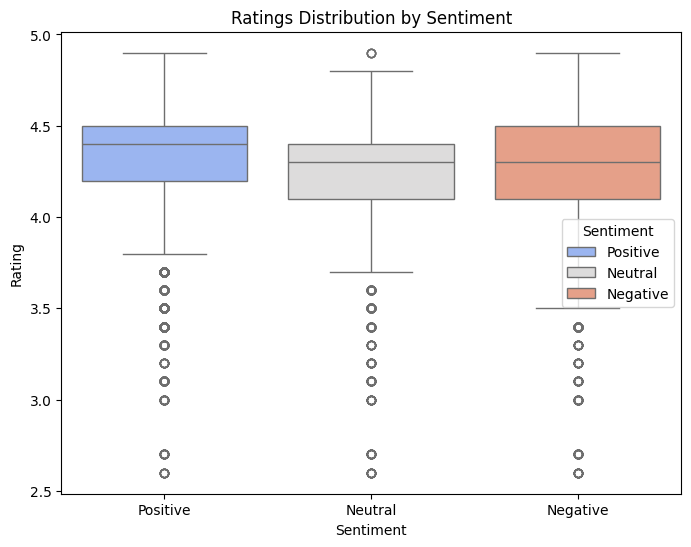

In [98]:
# Merge reviews with apps to bring in Rating info
reviews_with_rating = reviews.merge(apps[['App','Rating']], on='App', how='left')

# Ratings by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x='Sentiment', y='Rating', hue='Sentiment', data=reviews_with_rating, palette='coolwarm')
plt.title("Ratings Distribution by Sentiment")
plt.show()

### Ratings by Sentiment
**Impact:**  
Positive sentiments align with higher ratings, while negative sentiments cluster around lower ratings.  
This confirms that textual feedback and star ratings reinforce each other, making sentiment analysis a valuable complement to numerical ratings.

## Sentiment Analysis
In this step, we analyzed user reviews to understand sentiment trends.

**Impact:** 
- The majority of reviews are positive, confirming overall satisfaction, but negative feedback highlights critical improvement areas.
- Categories with high engagement (Games, Social, Entertainment) show both strong praise and criticism, while ratings and sentiments consistently align, making sentiment analysis a valuable complement to numerical ratings.

---

# Final Insights & Recommendations

---

## Key Findings
Our analysis of Google Play Store apps revealed several critical dynamics:

1. **User Adoption & Visibility**
   - Installs are highly skewed: a few apps dominate downloads while most remain niche.
   - Reviews strongly correlate with installs, acting as a feedback loop that boosts visibility and credibility.
   - Ratings are consistently high across categories, limiting their usefulness as a differentiator.

2. **Pricing Strategy**
   - Free apps overwhelmingly outperform paid apps in installs.
   - Successful monetization relies on freemium models, ads, or in-app purchases rather than upfront costs.

3. **Category Dynamics**
   - Games, Communication, and Social apps dominate installs and reviews, showing where user demand is concentrated.
   - Education and Health apps achieve strong ratings, reflecting satisfaction in niche but valuable categories.

4. **Top Apps Benchmarking**
   - A handful of apps set benchmarks for installs and reviews, defining market visibility standards.
   - High ratings alone do not guarantee success; adoption and engagement are stronger drivers.

5. **Sentiment Insights**
   - Majority of reviews are positive, confirming overall satisfaction.
   - Negative feedback highlights critical improvement areas, especially in high-engagement categories (Games, Social, Entertainment).
   - Sentiment aligns with ratings, validating that textual feedback complements numerical scores.

---

## Recommendations
- **Break the Visibility Barrier:**  
  Encourage reviews through in-app prompts and engagement campaigns to trigger the installs → reviews → visibility cycle. This helps smaller apps compete with dominant players.

- **Adopt Freemium Models:**  
  Keep entry free to maximize adoption, then monetize via ads, subscriptions, or in-app purchases. Paid‑only models restrict reach and reduce competitiveness.

- **Strategic Category Targeting:**  
  Compete in high-demand categories (Games, Social, Communication) with differentiation strategies, or focus on niche categories (Education, Health) where strong ratings can build trust and loyalty.

- **Leverage Sentiment Analysis:**  
  Use negative reviews as direct input for product improvement. Addressing pain points in user experience can convert dissatisfied users into advocates.

- **Benchmark Against Leaders:**  
  Study top apps’ engagement, UI/UX, and marketing strategies. Replicating proven tactics while innovating on differentiation can accelerate growth.


---

# Conclusion
**App success is not driven by ratings alone.**  
It requires solving the visibility challenge (installs + reviews), adopting user‑friendly pricing strategies, targeting the right categories, and continuously improving based on sentiment feedback.  

**Impact:** Developers who integrate these insights can break into competitive markets, maximize adoption, and sustain growth through engagement and user satisfaction.

---